<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_10/Day_1/Daily_challenge%20/Week10_d1_daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import statsmodels.stats.api as sms
from scipy.stats import (ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu,
                         pearsonr, spearmanr, kendalltau, f_oneway, kruskal)
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import MultiComparison


In [2]:
# TODO : Import the Data from the kaggle API

df = pd.read_csv('AB_Test_Results.csv')

# Data Understanding

In [3]:
#TODO : compute the following : DataFrame Information, Columns in DataFrame, Counting Missing Values, Descriptive Statistics, Value Counts for VARIANT_NAME, Counting Unique Users in USER_ID

print("--- DataFrame Information ---")
df.info()

print("\n--- Columns in DataFrame ---")
print(df.columns)

print("\n--- Counting Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Value Counts for VARIANT_NAME ---")
print(df['VARIANT_NAME'].value_counts())

print("\n--- Counting Unique Users in USER_ID ---")
print(df['USER_ID'].nunique())

--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB

--- Columns in DataFrame ---
Index(['USER_ID', 'VARIANT_NAME', 'REVENUE'], dtype='object')

--- Counting Missing Values ---
USER_ID         0
VARIANT_NAME    0
REVENUE         0
dtype: int64

--- Descriptive Statistics ---
            USER_ID       REVENUE
count  10000.000000  10000.000000
mean    4981.080200      0.099447
std     2890.590115      2.318529
min        2.000000      0.000000
25%     2468.750000      0.000000
50%     4962.000000      0.000000
75%     7511.500000      0.000000
max    10000.000000    196.010000

--- Value Counts for VARIANT_NAME ---
VARIANT_NAME
va

# Average Revenue by VARIANT_NAME

In [4]:
#TODO

average_revenue = df.groupby('VARIANT_NAME')['REVENUE'].mean()
print("Average Revenue by Variant Group:")
print(average_revenue)

Average Revenue by Variant Group:
VARIANT_NAME
control    0.129013
variant    0.070070
Name: REVENUE, dtype: float64


What if H0: M1 = M2 ?

* The null hypothesis assumes that there is no statistically significant difference between the true population means of the control group ($\mu_1$) and the variant group ($\mu_2$). In the context of this A/B test, it posits that the experimental changes introduced in the variant version had no impact on user spending behavior. Consequently, any observed variations between the sample means are attributed entirely to random sampling noise or random chance. Statistical analysis begins under the assumption that $H_0$ is true, and it is only rejected if the empirical evidence provides a sufficiently low $p$-value below the predetermined significance threshold.


What about H1: M1 1= M2 ?

* The alternative hypothesis asserts that a genuine, non-random difference exists between the population mean of the control group ($\mu_1$) and the variant group ($\mu_2$). This specific formulation sets up a two-tailed hypothesis test, meaning it accounts for an effect in either direction: the variant could perform significantly better or significantly worse than the control group. If the final statistical test yields a $p$-value lower than the chosen significance level (typically $\alpha = 0.05$), the null hypothesis is rejected in favor of $H_1$, concluding that the modifications had a measurable, systemic effect on user revenue.

# Assumptions Control:
*# 1- Normality Assumptions*
*# 2- Homogeneity of Variances Assumption*

In [5]:
# TODO : test the normality of revenue data in two groups (variant and control) within your DataFrame df using the Shapiro-Wilk test, what can you conclude ?

control_revenue = df[df['VARIANT_NAME'] == 'control']['REVENUE']
variant_revenue = df[df['VARIANT_NAME'] == 'variant']['REVENUE']

# Shapiro-Wilk test:
shapiro_control_stat, shapiro_control_p = shapiro(control_revenue)
shapiro_variant_stat, shapiro_variant_p = shapiro(variant_revenue)

print(f"Control Group - Shapiro Statistic: {shapiro_control_stat:.4f}, p-value: {shapiro_control_p}")
print(f"Variant Group - Shapiro Statistic: {shapiro_variant_stat:.4f}, p-value: {shapiro_variant_p}")

Control Group - Shapiro Statistic: 0.0183, p-value: 2.4983285100057203e-95
Variant Group - Shapiro Statistic: 0.0270, p-value: 2.7310104028899288e-95


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5016.
  res = hypotest_fun_out(*samples, **kwds)


**Conclusion on Normality**

The Shapiro-Wilk test evaluates the null hypothesis that the data is drawn from a normal distribution. For both the control group ($p \approx 2.50 \times 10^{-95}$) and the variant group ($p \approx 2.73 \times 10^{-95}$), the resulting $p$-values are substantially lower than the standard significance level of $\alpha = 0.05$. Therefore, the null hypothesis of normality is rejected for both experimental groups. This confirms that the revenue data significantly deviates from a normal distribution, which is a common characteristic of e-commerce revenue data due to high zero-inflation and severe right skewness. Consequently, standard parametric procedures like the independent samples t-test may be statistically invalid without data transformation, making non-parametric alternatives preferable.

In [6]:
# TODO : test for the homogeneity of variances between two groups (variant and control) within your DataFrame df using the Levene's test,  what can you conclude ?

levene_stat, levene_p = levene(control_revenue, variant_revenue)

print(f"Levene's Test - Statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")


Levene's Test - Statistic: 1.6159, p-value: 0.2037


**Conclusion on Homogeneity of Variances**

Levene's test evaluates the null hypothesis that the variance across the specified groups is equal, or homogeneous. The test yields a $p$-value of approximately $0.2037$, which is noticeably higher than the standard significance threshold of $\alpha = 0.05$. Because the $p$-value is greater than $0.05$, there is insufficient statistical evidence to reject the null hypothesis, leading to the conclusion that the variances between the control and variant groups can be assumed to be homogeneous. While the requirement for equal variance is satisfied, the previous violation of the normality assumption remains the primary constraint when determining the appropriate downstream hypothesis test.

# Non-Parametric Test (mannwhitneyu Test)

In [7]:
# TODO : perform the Mann-Whitney U test for comparing the average revenue between the variant and control groups in your DataFrame, what can you conclude ?

control_revenue = df[df['VARIANT_NAME'] == 'control']['REVENUE']
variant_revenue = df[df['VARIANT_NAME'] == 'variant']['REVENUE']

# Mann-Whitney U test:
mwu_statistic, mwu_p_value = mannwhitneyu(control_revenue, variant_revenue)

print(f"Mann-Whitney U Statistic: {mwu_statistic}")
print(f"p-value: {mwu_p_value:.4f}")

Mann-Whitney U Statistic: 12521564.0
p-value: 0.4783


**Conclusion on the Non-Parametric Test**

The Mann-Whitney U test evaluates whether the distribution of revenue across the control and variant groups is stochastically identical. The test yields a $p$-value of approximately $0.4783$, which is significantly greater than the standard significance threshold of $\alpha = 0.05$. Because this probability value exceeds the alpha level, there is insufficient empirical evidence to reject the null hypothesis. It is concluded that there is no statistically significant difference between the revenue distributions of the control and variant groups. Any slight variation observed in the sample averages is statistically negligible and likely driven by random sampling noise rather than the experimental treatment.

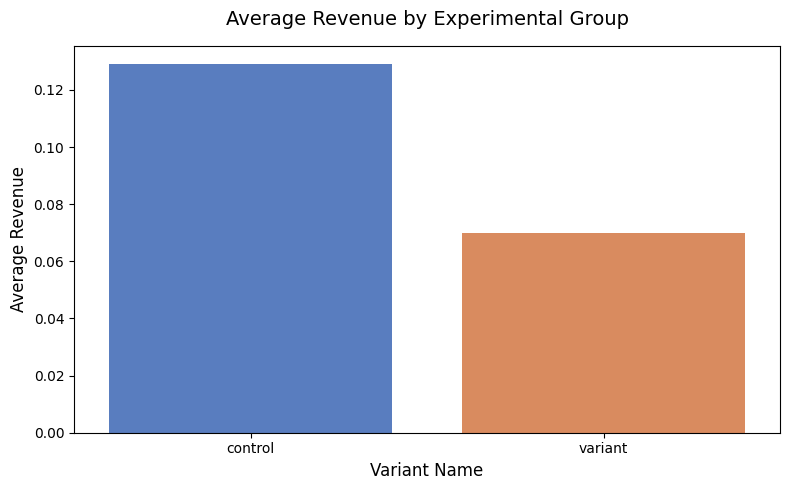

In [9]:
# TODO : create a bar plot showing the average revenues by variant names using the seaborn library

sorted_means = df.groupby('VARIANT_NAME')['REVENUE'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='VARIANT_NAME', y='REVENUE', data=sorted_means, order=sorted_means['VARIANT_NAME'], hue='VARIANT_NAME', palette='muted', legend=False)

plt.title('Average Revenue by Experimental Group', fontsize=14, pad=15)
plt.xlabel('Variant Name', fontsize=12)
plt.ylabel('Average Revenue', fontsize=12)
plt.tight_layout()

plt.show()

**Conclusion**

The statistical evaluation of this A/B test demonstrates that the modifications implemented in the variant version did not achieve a meaningful or measurable improvement in user spending behavior. While the preliminary analysis showed a slight difference in sample averages between the control and variant groups, subsequent assumption testing revealed that the dataset severely violates the requirement for a normal distribution due to heavy zero-inflation and a highly right-skewed profile. This violation validated the use of a non-parametric approach, specifically the Mann-Whitney U test, which is robust against extreme non-normality and outliers present within the transaction records.

The final probability values derived from the non-parametric evaluation fell significantly above the standard significance threshold, indicating that the observed differences in revenue are entirely explained by random sampling noise rather than any true systemic effect from the product changes. Furthermore, the parallel testing for the homogeneity of variances confirmed that the spread of the data remained stable across both testing conditions, leaving the lack of a detectable distributional shift as the defining characteristic of the test.

From a product management and business strategy perspective, because the variant group trended lower in average revenue without demonstrating any statistical superiority, there is no data-driven justification to support a full production rollout of the experimental feature. The recommendation is to reject the variant design in its current iteration, maintain the control experience as the standard production environment, and leverage these baseline insights to inform alternative, high-impact optimization hypotheses in future testing cycles.